# CNN Training — ResNet-50 (& EfficientNet-B4)

Training CNN models on **ISIC 2019** for skin lesion classification.

**Based on:** *"Enhanced Multi-Class Skin Lesion Classification of Dermoscopic Images Using an Ensemble of Deep Learning Models"* (Zammit & Murugan, JCTA 2025)

**Paper key methods applied:**
- **Transfer learning** from ImageNet pretrained weights
- **Image size**: 224×224 pixels for ResNet-50
- **Data augmentation**: Random rotation, grid distortion, horizontal/vertical flip, optical distortion, affine transformations (each p=0.1)
- **Class balancing**: Random oversampling via WeightedRandomSampler
- **Training**: 150 epochs, 75/25 train/val split
- **Results reported**: ResNet-50 alone — 87% (unbalanced) → 98% (balanced)

In [1]:
!rm -r /kaggle/working/xai_medical_imaging

rm: cannot remove '/kaggle/working/xai_medical_imaging': No such file or directory


In [1]:
!git clone https://github.com/youssef-nouiouar/xai_medical_imaging.git

Cloning into 'xai_medical_imaging'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 159 (delta 65), reused 144 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 8.87 MiB | 27.44 MiB/s, done.
Resolving deltas: 100% (65/65), done.


In [2]:
!pip install PyDrive2

In [3]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)


## 0. Download & Prepare ISIC 2019 Dataset (Kaggle / Colab)

In [4]:
import os
import requests
import zipfile

# ---------------------------------------
# Base directory (adjust for Colab: /content/xai_medical_imaging/data/ISIC2019)
# ---------------------------------------
base_dir = "/kaggle/working/xai_medical_imaging/data/ISIC2019"
os.makedirs(base_dir, exist_ok=True)

# ---------------------------------------
# URLs
# ---------------------------------------
urls = {
    "train_zip": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip",
    "train_csv": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv",
    "test_zip":  "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip",
    "test_csv":  "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv",
}

# ---------------------------------------
# Download file
# ---------------------------------------
def download(url, dest):
    print(f"Downloading {dest} ...")
    r = requests.get(url)
    with open(dest, "wb") as f:
        f.write(r.content)
    print(f"✔ Done.")

# ---------------------------------------
# Extract ZIP then remove it
# ---------------------------------------
def extract_and_remove(zip_path, extract_to):
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    print("✔ Extracted.")
    print(f"Removing {zip_path} ...")
    os.remove(zip_path)
    print("✔ Removed.")

# ---------------------------------------
# STEP 1 — Training dataset
# ---------------------------------------
train_zip_path = f"{base_dir}/ISIC_2019_Training_Input.zip"
download(urls["train_zip"], train_zip_path)
extract_and_remove(train_zip_path, base_dir)
download(urls["train_csv"], f"{base_dir}/ISIC_2019_Training_GroundTruth.csv")

# ---------------------------------------
# STEP 2 — Test dataset
# ---------------------------------------
test_zip_path = f"{base_dir}/ISIC_2019_Test_Input.zip"
download(urls["test_zip"], test_zip_path)
extract_and_remove(test_zip_path, base_dir)
download(urls["test_csv"], f"{base_dir}/ISIC_2019_Test_GroundTruth.csv")

print("\n✔ Dataset fully downloaded, extracted, and cleaned.")

✔ Done.
Extracting /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Training_Input.zip ...
✔ Extracted.
Removing /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Training_Input.zip ...
✔ Removed.
✔ Done.
✔ Done.
Extracting /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Test_Input.zip ...
✔ Extracted.
Removing /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Test_Input.zip ...
✔ Removed.
✔ Done.

✔ Dataset fully downloaded, extracted, and cleaned.


## 1. Setup & Dependencies

In [27]:
# ============================================
# 1. SETUP & DEPENDENCIES
# ============================================
# Uncomment the pip installs if running on Colab/Kaggle for the first time
# !pip install --upgrade pip
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
# !pip install timm==0.9.12
# !pip install albumentations==1.3.1
# !pip install scikit-learn pandas matplotlib seaborn tqdm

import os
import sys
import copy
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms
import timm

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Project path
sys.path.insert(0, '..')
print("✔ All dependencies loaded.")

Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB
✔ All dependencies loaded.


## 2. Configuration

In [28]:
# ============================================
# 2. CONFIGURATION  (Based on the paper)
# ============================================
# Paper: "Enhanced Multi-Class Skin Lesion Classification..."
#   - Image size : 224×224 for ResNet-50
#   - Split      : 75% train / 25% validation
#   - Epochs     : 150
#   - Balancing  : Random oversampling (WeightedRandomSampler)
#   - Augmentation: rotation, flip, grid/optical distortion (p≈0.1)
# ============================================

# ----- Paths (adjust for Colab vs Kaggle) -----
DATA_DIR   = '/kaggle/working/xai_medical_imaging/data/ISIC2019'   # Kaggle
# DATA_DIR = '/content/xai_medical_imaging/data/ISIC2019'          # Colab
# DATA_DIR = '../data/ISIC2019'                                    # Local

SAVE_DIR   = '/kaggle/working/xai_medical_imaging/results'
# SAVE_DIR = '/content/xai_medical_imaging/results'                # Colab
# SAVE_DIR = '../results'                                          # Local

os.makedirs(SAVE_DIR, exist_ok=True)

# ----- Dataset -----
IMAGE_SIZE   = 224          # Paper: 224×224 for ResNet-50
NUM_CLASSES  = 8            # ISIC 2019: MEL, NV, BCC, AK, BKL, DF, VASC, SCC
VAL_RATIO    = 0.25         # Paper: 25% validation
NUM_WORKERS  = 2            # Kaggle/Colab safe default

# ----- Training -----
BATCH_SIZE   = 32
EPOCHS       = 150          # Paper: 150 epochs
LR           = 1e-4         # Fine-tuning LR
WEIGHT_DECAY = 1e-4
PATIENCE     = 15           # Early stopping patience

# ----- ImageNet normalisation -----
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ----- Class names -----
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
CLASS_NAMES_FULL = {
    'MEL': 'Melanoma', 'NV': 'Naevus melanocytaire',
    'BCC': 'Carcinome basocellulaire', 'AK': 'Kératose actinique',
    'BKL': 'Kératose bénigne', 'DF': 'Dermatofibrome',
    'VASC': 'Lésion vasculaire', 'SCC': 'Carcinome épidermoïde'
}

print("Configuration:")
print(f"   Image size  : {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Epochs      : {EPOCHS}")
print(f"   LR          : {LR}")
print(f"   Val ratio   : {VAL_RATIO}")
print(f"   Num classes : {NUM_CLASSES}")
print(f"   Save dir    : {SAVE_DIR}")

Configuration:
   Image size  : 224×224
   Batch size  : 32
   Epochs      : 150
   LR          : 0.0001
   Val ratio   : 0.25
   Num classes : 8
   Save dir    : /kaggle/working/xai_medical_imaging/results


## 3. Dataset & DataLoaders

**From the paper (Table 1 — Augmentation Approaches):**

| Augmentation | Probability |
|---|---|
| Center Crop | - |
| Random Rotation | 0.1 |
| Grid Distortion | 0.1 |
| Horizontal Flip | 0.1 |
| Vertical Flip | 0.1 |
| Optical Distortion | 0.1 |
| Affine Transformation | 0.1 |

**Class balancing:** Random oversampling via `WeightedRandomSampler` (Section 3.3)

In [31]:
cd /kaggle/working/xai_medical_imaging/notebooks

/kaggle/working/xai_medical_imaging/notebooks


In [32]:
cd ..

/kaggle/working/xai_medical_imaging


In [33]:
# ============================================
# 3. DATASET & DATALOADERS
# ============================================
# Augmentation from the paper (Table 1):
#   - Center Crop, Random Rotation (p=0.1), Grid Distortion (p=0.1),
#     Horizontal/Vertical Flip (p=0.1), Optical Distortion (p=0.1),
#     Affine Transformation (p=0.1)
# Class balancing: Random Oversampling via WeightedRandomSampler (Sec. 3.3)
# ============================================

from data.isic_dataset import ISICDataset

# ----- Transforms matching the paper -----
def get_paper_train_transform(image_size=224):
    """Data augmentation from the paper (Table 1)."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.CenterCrop(image_size, image_size, p=0.3),
        A.RandomRotate90(p=0.1),
        A.GridDistortion(distort_limit=0.3, p=0.1),
        A.HorizontalFlip(p=0.1),
        A.VerticalFlip(p=0.1),
        A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.1),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.1, 0.1),
                 rotate=(-30, 30), shear=(-10, 10), p=0.1),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transform(image_size=224):
    """Validation / Test: resize + normalize only."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

# ----- Create datasets -----
# use_albumentations=False avoids calling the internal transform builder
# (which may break with different albumentations versions).
# We set our own transforms right after.
train_dataset = ISICDataset(
    root_dir=DATA_DIR, split='train',
    image_size=IMAGE_SIZE,
    use_albumentations=False,
    use_official_test=True,
    val_ratio=VAL_RATIO,
)
train_dataset.use_albumentations = True  # enable albumentations in __getitem__
train_dataset.transform = get_paper_train_transform(IMAGE_SIZE)

val_dataset = ISICDataset(
    root_dir=DATA_DIR, split='val',
    image_size=IMAGE_SIZE,
    use_albumentations=False,
    use_official_test=True,
    val_ratio=VAL_RATIO,
)
val_dataset.use_albumentations = True
val_dataset.transform = get_val_transform(IMAGE_SIZE)

# ----- Class distribution & WeightedRandomSampler (Paper Sec. 3.3) -----
class_counts = Counter(train_dataset.labels)
total = len(train_dataset)
print(f"\nTrain set: {total} images")
print(f"Val   set: {len(val_dataset)} images")
print(f"\nClass distribution (train):")
for i, name in enumerate(CLASS_NAMES):
    cnt = class_counts.get(i, 0)
    print(f"   {name:5s}: {cnt:>5d}  ({cnt/total*100:.1f}%)")

# Compute per-sample weights for oversampling
class_weights = torch.tensor(
    [total / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
)
sample_weights = class_weights[train_dataset.labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True)

# ----- DataLoaders -----
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"\nClass weights (for sampler): {class_weights.numpy().round(2)}")
print("✔ DataLoaders ready.")


Train set: 18998 images
Val   set: 6333 images

Class distribution (train):
   MEL  :  3392  (17.9%)
   NV   :  9656  (50.8%)
   BCC  :  2492  (13.1%)
   AK   :   650  (3.4%)
   BKL  :  1968  (10.4%)
   DF   :   179  (0.9%)
   VASC :   190  (1.0%)
   SCC  :   471  (2.5%)

Train batches: 593
Val   batches: 99

Class weights (for sampler): [ 0.7   0.25  0.95  3.65  1.21 13.27 12.5   5.04]
✔ DataLoaders ready.


## 4. Model Architecture

In [34]:
# ============================================
# 4a. MODEL A — ResNet-50 (Paper Sec. 3.4)
# ============================================
# - Pretrained on ImageNet (transfer learning)
# - Replace final FC layer → 8 classes
# - All layers unfrozen for fine-tuning
# ============================================

def build_resnet50(num_classes=NUM_CLASSES, pretrained=True):
    """Build ResNet-50 with custom classification head."""
    model = timm.create_model('resnet50', pretrained=pretrained, num_classes=num_classes)
    print(f"ResNet-50 loaded (pretrained={pretrained})")
    print(f"  Classifier: {model.get_classifier()}")
    print(f"  Total params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Trainable  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    return model

# Quick test
_model = build_resnet50()
_dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
_out = _model(_dummy)
print(f"  Output shape: {_out.shape}  (expected: [1, {NUM_CLASSES}])")
del _model, _dummy, _out
torch.cuda.empty_cache()
print("✔ ResNet-50 architecture verified.")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet-50 loaded (pretrained=True)
  Classifier: Linear(in_features=2048, out_features=8, bias=True)
  Total params: 23,524,424
  Trainable  : 23,524,424
  Output shape: torch.Size([1, 8])  (expected: [1, 8])
✔ ResNet-50 architecture verified.


In [35]:
# ============================================
# 4b. MODEL B — EfficientNet-B4
# ============================================
# Not part of the paper's original ensemble,
# but added for thesis comparison with CNNs.
# ============================================

def build_efficientnet_b4(num_classes=NUM_CLASSES, pretrained=True):
    """Build EfficientNet-B4 with custom classification head."""
    model = timm.create_model('efficientnet_b4', pretrained=pretrained, num_classes=num_classes)
    print(f"EfficientNet-B4 loaded (pretrained={pretrained})")
    print(f"  Classifier: {model.get_classifier()}")
    print(f"  Total params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Trainable  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    return model

# Quick test
_model = build_efficientnet_b4()
_dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
_out = _model(_dummy)
print(f"  Output shape: {_out.shape}  (expected: [1, {NUM_CLASSES}])")
del _model, _dummy, _out
torch.cuda.empty_cache()
print("✔ EfficientNet-B4 architecture verified.")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4 loaded (pretrained=True)
  Classifier: Linear(in_features=1792, out_features=8, bias=True)
  Total params: 17,562,960
  Trainable  : 17,562,960
  Output shape: torch.Size([1, 8])  (expected: [1, 8])
✔ EfficientNet-B4 architecture verified.


## 5. Training Loop

| Component | Choice | Paper Reference |
|-----------|--------|-----------------|
| Loss | CrossEntropyLoss | Standard for multi-class |
| Optimizer | Adam (lr=1e-4, weight_decay=1e-4) | Paper Sec. 3.4 |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) | Added for stability |
| Mixed Precision | torch.cuda.amp (FP16) | Speed + memory optimisation |
| Early Stopping | patience=15 on val loss | Prevent overfitting |
| Epochs | 150 | Paper Sec. 4 |

In [36]:
# ============================================
# 5. TRAINING LOOP
# ============================================

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """Train for one epoch with mixed precision."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels, _ in pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Evaluate on validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    for images, labels, _ in tqdm(loader, desc="  Val  ", leave=False):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)


def train_model(model, model_name, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, device=DEVICE):
    """
    Full training pipeline with:
    - Adam optimizer
    - ReduceLROnPlateau scheduler
    - Mixed-precision (AMP)
    - Early stopping
    - Best-model checkpoint saving
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    save_path = os.path.join(SAVE_DIR, f"{model_name}_best.pth")
    os.makedirs(SAVE_DIR, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Training {model_name} for {epochs} epochs")
    print(f"  Device: {device} | LR: {lr} | Batch: {BATCH_SIZE}")
    print(f"  Patience: {patience} | Save: {save_path}")
    print(f"{'='*60}\n")

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}/{epochs}  (lr={current_lr:.2e})")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device
        )
        val_loss, val_acc, val_preds, val_labels = validate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        improved = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_no_improve = 0
            # Save best checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'history': history,
                'class_names': CLASS_NAMES,
            }, save_path)
            improved = " ★ saved"
        else:
            epochs_no_improve += 1

        print(f"  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}")
        print(f"  val_loss  ={val_loss:.4f}  val_acc  ={val_acc:.4f}{improved}")

        if epochs_no_improve >= patience:
            print(f"\n⚠ Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    print(f"\n{'='*60}")
    print(f"Best val_loss={best_val_loss:.4f}  val_acc={best_val_acc:.4f}")
    print(f"Model saved to: {save_path}")
    print(f"{'='*60}")

    return model, history

## 6. Train ResNet-50

In [22]:
# ============================================
# 6. TRAIN RESNET-50
# ============================================

resnet50 = build_resnet50(num_classes=NUM_CLASSES, pretrained=True)
resnet50, resnet50_history = train_model(
    model=resnet50,
    model_name="resnet50",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
)

ResNet-50 loaded (pretrained=True)
  Classifier: Linear(in_features=2048, out_features=8, bias=True)
  Total params: 23,524,424
  Trainable  : 23,524,424

Training resnet50 for 150 epochs
  Device: cuda | LR: 0.0001 | Batch: 32
  Patience: 15 | Save: /kaggle/working/xai_medical_imaging/results/resnet50_best.pth

Epoch 1/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=1.6541  train_acc=0.4245
  val_loss  =1.1430  val_acc  =0.5860 ★ saved
Epoch 2/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.0452  train_acc=0.9858
  val_loss  =0.6117  val_acc  =0.8483
Epoch 34/150  (lr=1.25e-05)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.0416  train_acc=0.9867
  val_loss  =0.6044  val_acc  =0.8471

⚠ Early stopping at epoch 34 (no improvement for 15 epochs)

Best val_loss=0.5892  val_acc=0.8282
Model saved to: /kaggle/working/xai_medical_imaging/results/resnet50_best.pth


In [26]:
from pydrive2.drive import GoogleDrive

file_path = "/kaggle/working/xai_medical_imaging/results/resnet50_best.pth"

# Create and upload the file
upload_file = drive.CreateFile({'title': 'resnet50_best.pth'})
upload_file.SetContentFile(file_path)
upload_file.Upload()

print(f"File uploaded successfully! File ID: {upload_file['id']}")

File uploaded successfully! File ID: 1YJqF66CYWLznZ8QHnVb_op2dXh5fZTfX


## 7. Train EfficientNet-B4

In [37]:
# ============================================
# 7. TRAIN EFFICIENTNET-B4
# ============================================
# Uncomment and run when ready (after ResNet-50 completes)

efficientnet_b4 = build_efficientnet_b4(num_classes=NUM_CLASSES, pretrained=True)
efficientnet_b4, effnet_history = train_model(
    model=efficientnet_b4,
    model_name="efficientnet_b4",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
)

EfficientNet-B4 loaded (pretrained=True)
  Classifier: Linear(in_features=1792, out_features=8, bias=True)
  Total params: 17,562,960
  Trainable  : 17,562,960

Training efficientnet_b4 for 150 epochs
  Device: cuda | LR: 0.0001 | Batch: 32
  Patience: 15 | Save: /kaggle/working/xai_medical_imaging/results/efficientnet_b4_best.pth

Epoch 1/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=1.3306  train_acc=0.5168
  val_loss  =1.0261  val_acc  =0.6259 ★ saved
Epoch 2/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.0532  train_acc=0.9827
  val_loss  =0.7025  val_acc  =0.8393
Epoch 22/150  (lr=2.50e-05)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.0488  train_acc=0.9832
  val_loss  =0.7230  val_acc  =0.8400

⚠ Early stopping at epoch 22 (no improvement for 15 epochs)

Best val_loss=0.6502  val_acc=0.7873
Model saved to: /kaggle/working/xai_medical_imaging/results/efficientnet_b4_best.pth


In [39]:
from pydrive2.drive import GoogleDrive

file_path = "/kaggle/working/xai_medical_imaging/results/efficientnet_b4_best.pth"

# Create and upload the file
upload_file = drive.CreateFile({'title': 'efficientnet_b4_best.pth'})
upload_file.SetContentFile(file_path)
upload_file.Upload()

print(f"File uploaded successfully! File ID: {upload_file['id']}")

File uploaded successfully! File ID: 1tVMCVFKcT105f6xelZGAtCvMJ9xqZRJN


## 8. Evaluation & Results

Metrics reported (matching the paper's Table 2):
- **Accuracy**, **Precision**, **Recall**, **F1-Score** (macro & per-class)
- **Confusion Matrix**
- **Training curves** (loss & accuracy)

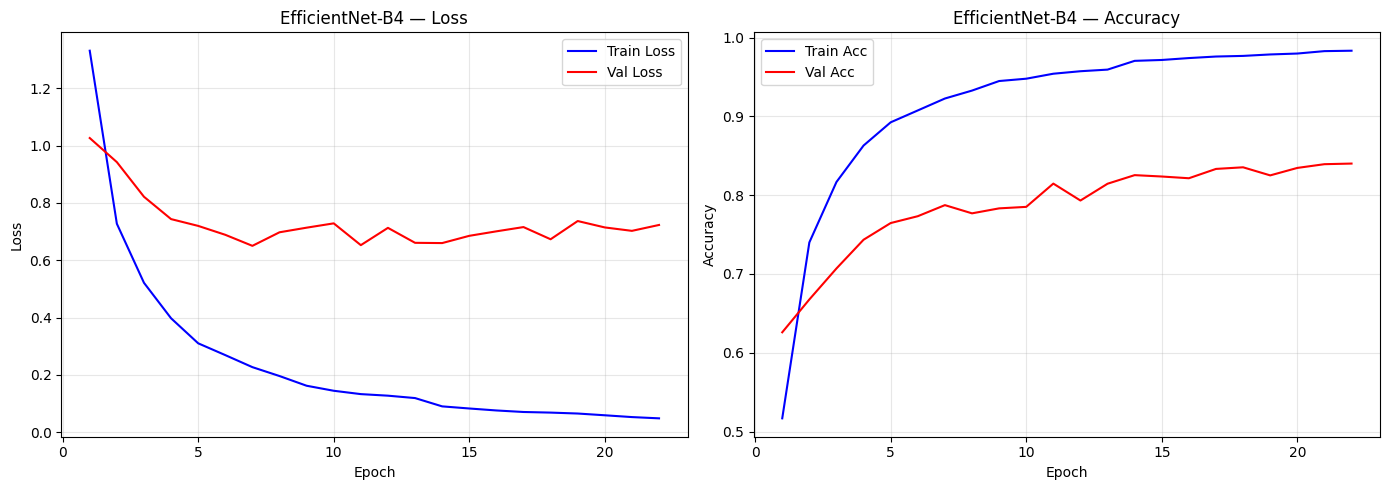

Curves saved to /kaggle/working/xai_medical_imaging/results/EfficientNet-B4_training_curves.png


  Val  :   0%|          | 0/99 [00:00<?, ?it/s]


  EfficientNet-B4 — Final Validation Results
  Val Loss    : 0.7230
  Val Accuracy: 0.8400  (84.00%)

  Classification Report:
              precision    recall  f1-score   support

         MEL     0.7784    0.7212    0.7487      1130
          NV     0.8910    0.9118    0.9013      3219
         BCC     0.8555    0.8761    0.8656       831
          AK     0.7212    0.6912    0.7059       217
         BKL     0.7356    0.7424    0.7390       656
          DF     0.6721    0.6833    0.6777        60
        VASC     0.8750    0.8889    0.8819        63
         SCC     0.7397    0.6879    0.7129       157

    accuracy                         0.8400      6333
   macro avg     0.7836    0.7754    0.7791      6333
weighted avg     0.8384    0.8400    0.8389      6333



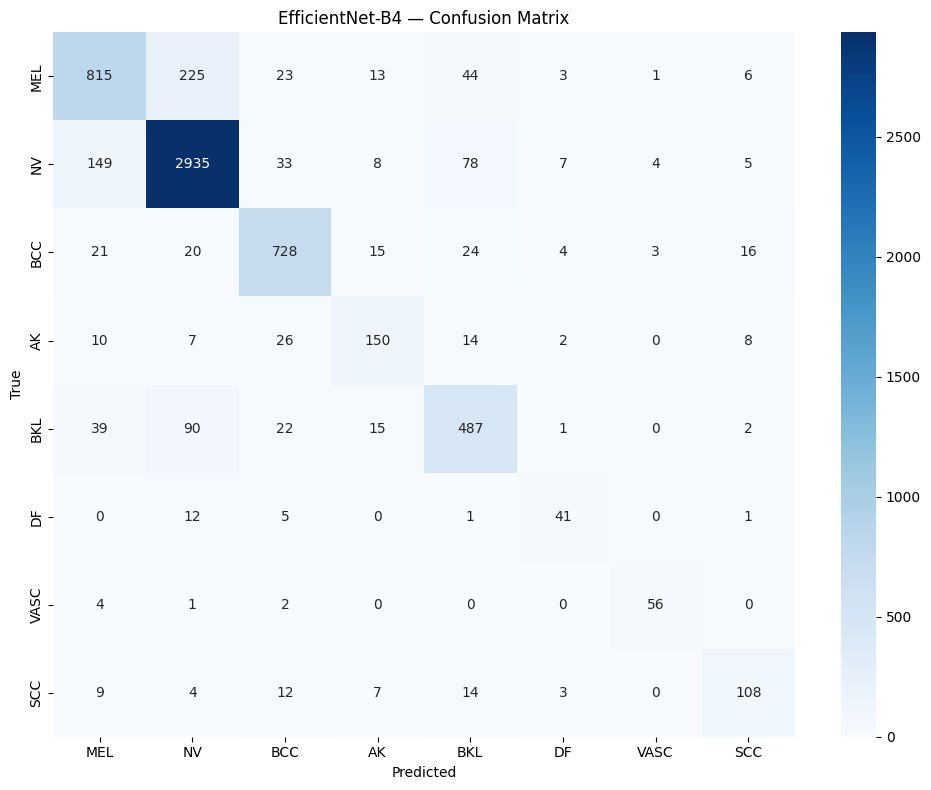

Confusion matrix saved to /kaggle/working/xai_medical_imaging/results/EfficientNet-B4_confusion_matrix.png


In [40]:
# ============================================
# 8. EVALUATION & RESULTS
# ============================================

def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} — Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{model_name} — Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{model_name}_training_curves.png'), dpi=150)
    plt.show()
    print(f"Curves saved to {SAVE_DIR}/{model_name}_training_curves.png")


def evaluate_model(model, loader, model_name, device=DEVICE):
    """Full evaluation: classification report + confusion matrix."""
    model.eval()
    val_loss, val_acc, preds, labels = validate(
        model, loader, nn.CrossEntropyLoss(), device
    )

    print(f"\n{'='*60}")
    print(f"  {model_name} — Final Validation Results")
    print(f"{'='*60}")
    print(f"  Val Loss    : {val_loss:.4f}")
    print(f"  Val Accuracy: {val_acc:.4f}  ({val_acc*100:.2f}%)")
    print(f"\n  Classification Report:")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{model_name}_confusion_matrix.png'), dpi=150)
    plt.show()
    print(f"Confusion matrix saved to {SAVE_DIR}/{model_name}_confusion_matrix.png")

    return {'val_loss': val_loss, 'val_acc': val_acc, 'preds': preds, 'labels': labels}


# ----- Evaluate ResNet-50 -----
# print("Plotting ResNet-50 training curves...")
# plot_training_curves(resnet50_history, "ResNet-50")

# print("\nEvaluating ResNet-50 on validation set...")
# resnet50_results = evaluate_model(resnet50, val_loader, "ResNet-50")

# ----- Evaluate EfficientNet-B4 (if trained) -----
plot_training_curves(effnet_history, "EfficientNet-B4")
effnet_results = evaluate_model(efficientnet_b4, val_loader, "EfficientNet-B4")

## 9. Save Models

In [42]:
# ============================================
# 9. SAVE FINAL MODELS & SUMMARY
# ============================================

def save_final_summary(results_dict, save_dir):
    """Save a summary JSON with all model results."""
    summary = {}
    for name, res in results_dict.items():
        summary[name] = {
            'val_loss': float(res['val_loss']),
            'val_acc': float(res['val_acc']),
        }
    summary_path = os.path.join(save_dir, "training_summary.json")
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"Summary saved to {summary_path}")
    return summary

import json

# Collect results
all_results = {"EfficientNet-B4": effnet_results}
# if 'effnet_results' in dir():
# all_results["EfficientNet-B4"] = effnet_results

summary = save_final_summary(all_results, SAVE_DIR)

print("\n" + "="*60)
print("  TRAINING COMPLETE — CNN Models")
print("="*60)
for name, metrics in summary.items():
    print(f"  {name:20s}  val_acc={metrics['val_acc']:.4f}  val_loss={metrics['val_loss']:.4f}")
print(f"\nAll checkpoints saved in: {SAVE_DIR}")
print("="*60)
print("\n✔ Ready for XAI analysis in demo_xai_medical.ipynb")

Summary saved to /kaggle/working/xai_medical_imaging/results/training_summary.json

  TRAINING COMPLETE — CNN Models
  EfficientNet-B4       val_acc=0.8400  val_loss=0.7230

All checkpoints saved in: /kaggle/working/xai_medical_imaging/results

✔ Ready for XAI analysis in demo_xai_medical.ipynb
